## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.ensemble import AdaBoostRegressor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from tensorflow.keras.models import load_model

import statistics

from matplotlib.pylab import rcParams
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import norm
import statsmodels.api as sm
import requests
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

## Import Data


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7822 entries, 2024-01-16 00:00:00 to 2024-12-07 00:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   importActiveEnergyT  7822 non-null   float64
 1   currentA             7822 non-null   float64
 2   currentB             7822 non-null   float64
 3   currentC             7822 non-null   float64
 4   voltageA             7822 non-null   float64
 5   voltageB             7822 non-null   float64
 6   voltageC             7822 non-null   float64
 7   activePowerT         7822 non-null   float64
 8   activePowerA         7822 non-null   float64
 9   activePowerB         7822 non-null   float64
 10  activePowerC         7822 non-null   float64
 11  voltageL12           7318 non-null   float64
 12  voltageL23           7318 non-null   float64
 13  voltageL31           7318 non-null   float64
dtypes: float64(14)
memory usage: 916.6 KB


## Time Series Cross Validation

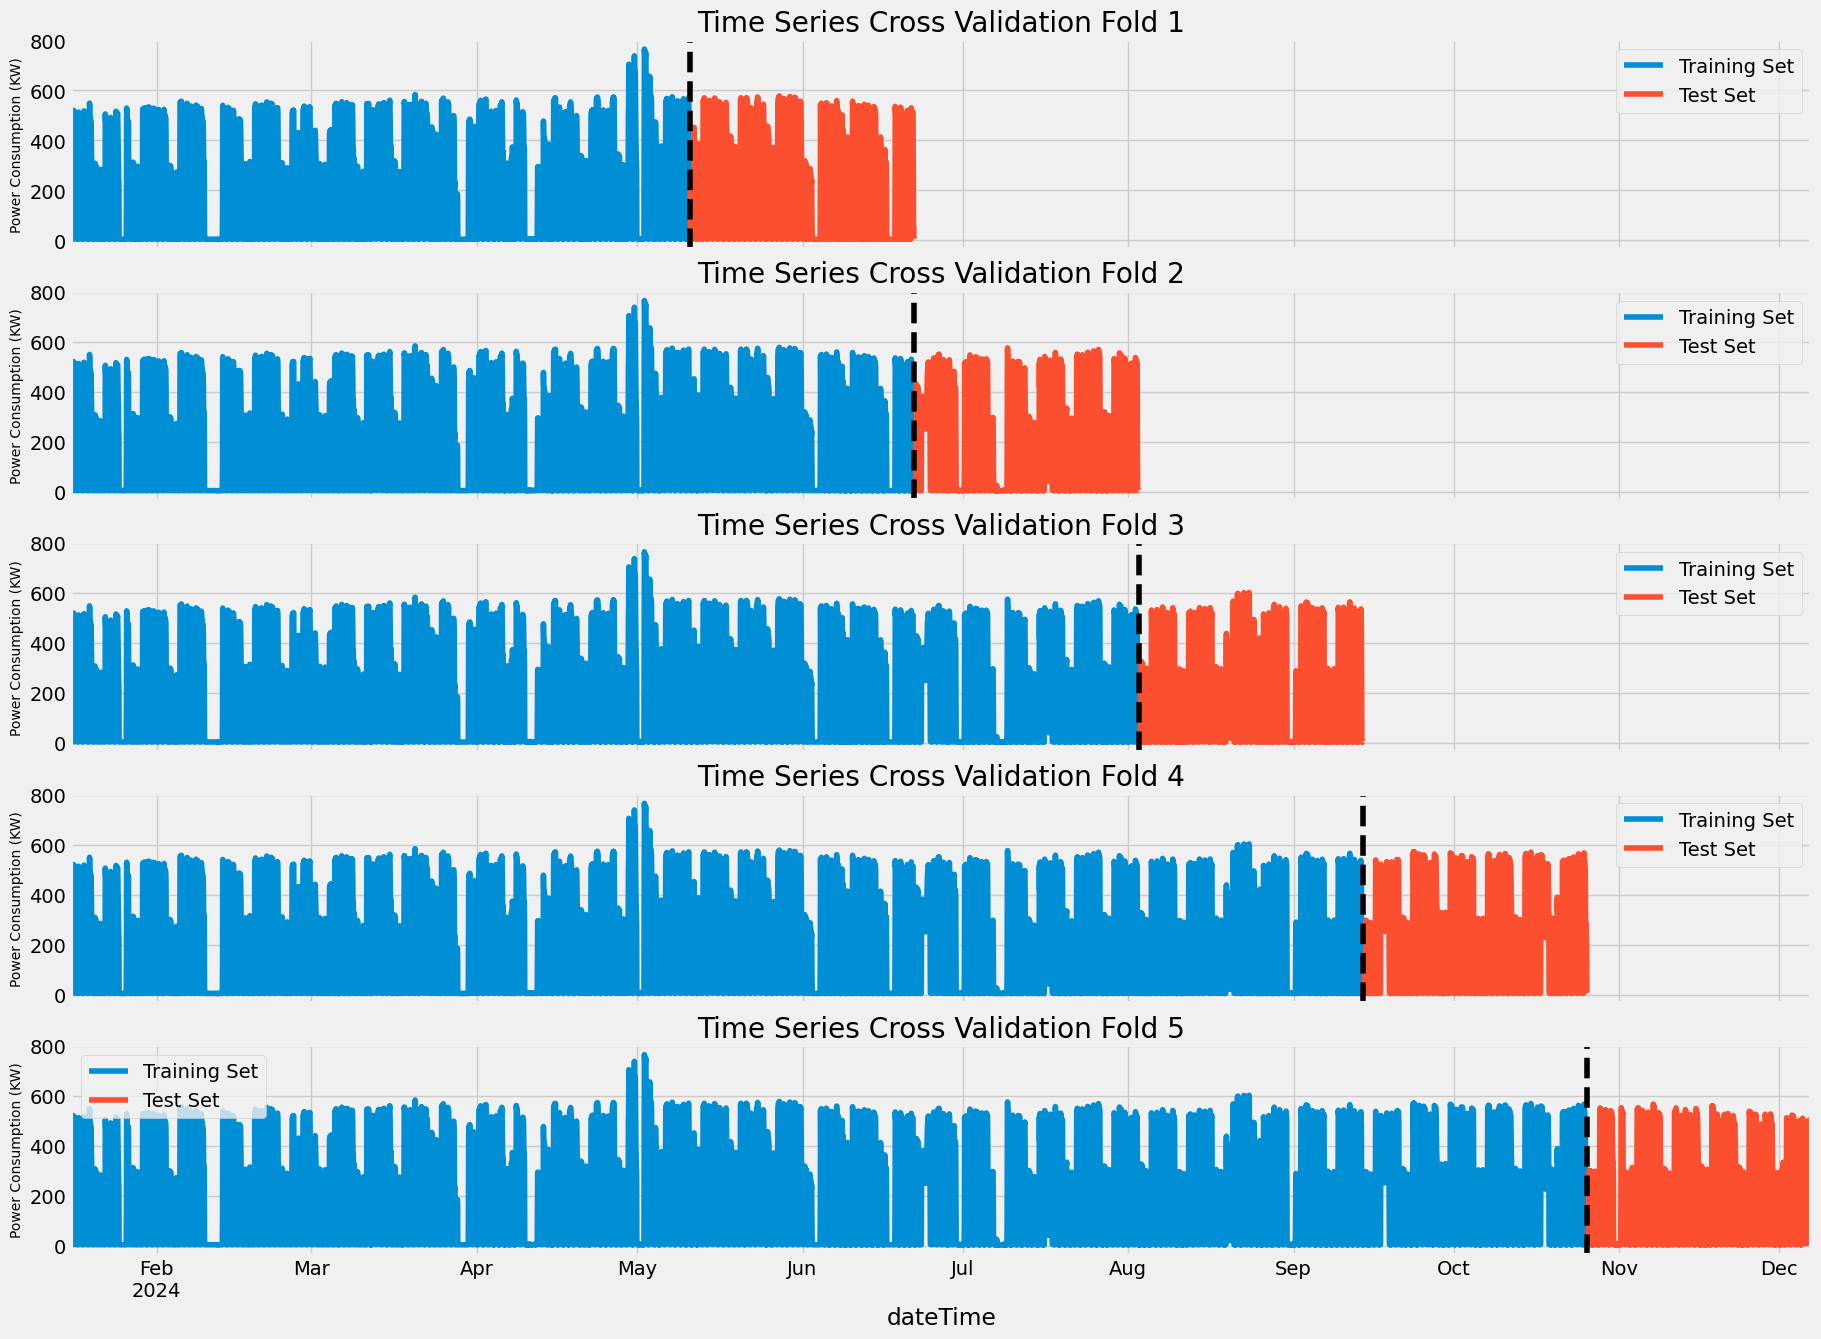

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=14*24*3, gap=0)
df = df.sort_index()
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(20,15))

fold = 0

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['activePowerT'].plot(ax=axs[fold], label='Training Set',title=f'Time Series Cross Validation Fold {fold+1}')
    test['activePowerT'].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    axs[fold].legend(['Training Set', 'Test Set'])
    axs[fold].set_ylabel('Power Consumption (KW)',fontsize=10)
    fold+=1

In [ ]:
def create_features(df, label=None):
    """
    Creates time series features from datetime index
    """
    df=df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    df['year'] = df.index.year
    return df

def add_lags(df):
  df = df.copy()
  target_map = df['activePowerT'].to_dict()
  df['lag1'] = (df.index-pd.Timedelta('7 days')).map(target_map)
  df['lag2'] = (df.index-pd.Timedelta('8 days')).map(target_map)
  df['lag3'] = (df.index-pd.Timedelta('9 days')).map(target_map)
  df['lag4'] = (df.index-pd.Timedelta('10 days')).map(target_map)
  target_mapAA = df['activePowerA'].to_dict()
  target_mapCA = df['currentA'].to_dict()

  df['activePowerA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapAA)
  df['currentA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapCA)
  df['activePowerA_lag2']=(df.index-pd.Timedelta('14 days')).map(target_mapAA)
  df['currentA_lag2']=(df.index-pd.Timedelta('14 days')).map(target_mapCA)
  return df

def df_to_X_y1(df, window_size=5):
  df = df.copy()
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][0]
    y.append(label)

  return np.array(X), np.array(y)



## Performance Evaluation Metrics

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def mean_absolute_scaled_error(y_true, y_pred):
    n = len(y_true)
    d = np.abs(np.diff(y_true)).sum()/(n-1)
    errors = np.abs(y_true - y_pred)
    return errors.mean()/d

## XGBoost

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)
df = add_lags(df)
df = create_features(df)

fold = 0
preds= []
xgb_score_mse = []
xgb_score_mae = []
xgb_score_r2 = []

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['hour','dayofweek','quarter','month','dayofyear','dayofmonth','weekofyear','activePowerA_lag1','currentA_lag1',"lag1"]


    TARGET = 'activePowerT'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]


    reg= xgb.XGBRegressor(
                          booster='gbtree',
                          n_estimators=3000,
                          early_stopping_rounds=100,
                          learning_rate=0.001,
                          objective='reg:absoluteerror',
                          max_depth=4,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8
                          )
    reg.fit(X_train,y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=1000)




    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    xgb_score_mse.append(mean_squared_error(y_test,y_pred))
    xgb_score_mae.append(mean_absolute_error(y_test,y_pred))
    xgb_score_r2.append(r2_score(y_test,y_pred))
    # score_mape.append( np.mean((np.abs(y_test - y_pred)) /((np.abs(y_test +np.abs(y_pred)) / 2))) * 100)
    # score_mase.append(mean_absolute_scaled_error(y_test,y_pred))
    # score_err.append((abs(statistics.mean(y_test)-statistics.mean(y_pred))/statistics.mean(y_test) * 100))




[0]	validation_0-mae:203.42273	validation_1-mae:205.40129
[1000]	validation_0-mae:97.25478	validation_1-mae:111.97488
[2000]	validation_0-mae:60.07176	validation_1-mae:80.26322
[2999]	validation_0-mae:46.96640	validation_1-mae:69.93853
[0]	validation_0-mae:203.83702	validation_1-mae:201.40372
[1000]	validation_0-mae:98.12162	validation_1-mae:94.46205
[2000]	validation_0-mae:61.29538	validation_1-mae:55.29160
[2999]	validation_0-mae:47.81887	validation_1-mae:42.31144
[0]	validation_0-mae:202.32181	validation_1-mae:189.99862
[1000]	validation_0-mae:95.20515	validation_1-mae:84.26365
[2000]	validation_0-mae:59.47583	validation_1-mae:48.75516
[2999]	validation_0-mae:46.89619	validation_1-mae:37.60316
[0]	validation_0-mae:199.21174	validation_1-mae:219.88266
[1000]	validation_0-mae:88.95376	validation_1-mae:98.53162
[2000]	validation_0-mae:55.34827	validation_1-mae:59.79918
[2999]	validation_0-mae:43.47671	validation_1-mae:47.91987
[0]	validation_0-mae:201.60057	validation_1-mae:202.90194
[

## XGBoost Forecasts

<Axes: title={'center': 'Basic vs Advanced Data Labelling (XGBoost)'}, xlabel='dateTime', ylabel='Power Consumption (KW)'>

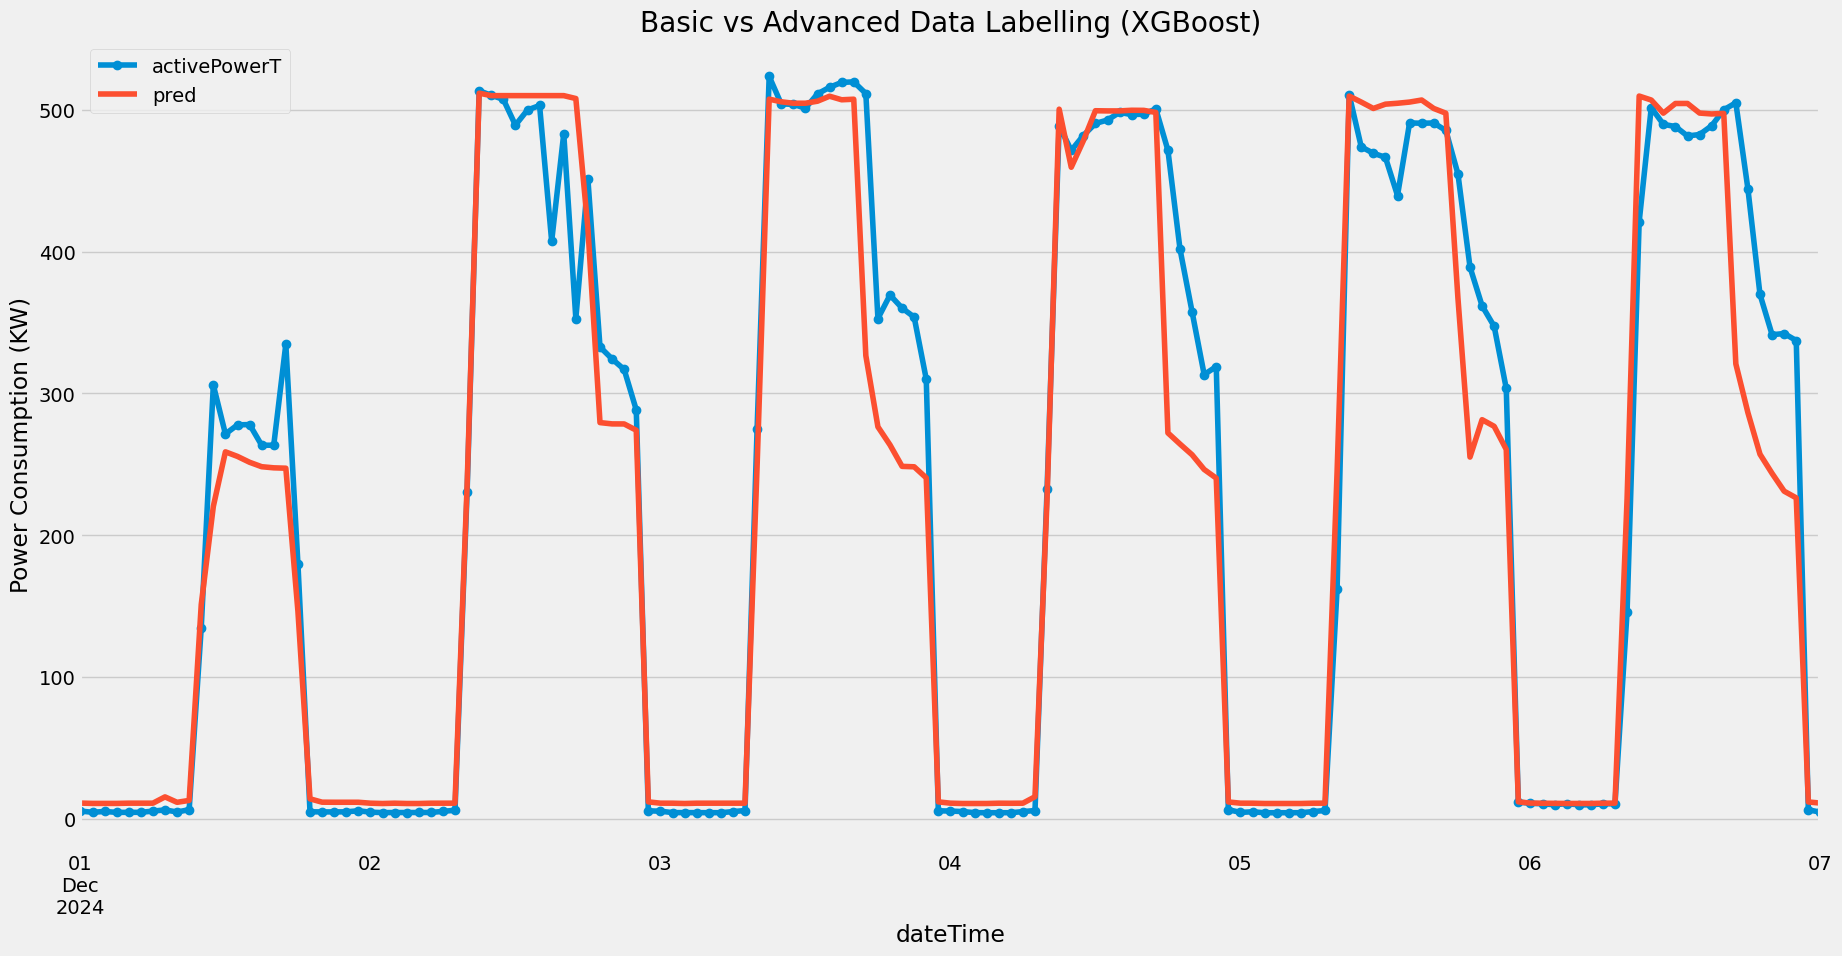

In [ ]:
df_xgb = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df_xgb['dateTime']= pd.to_datetime(df_xgb['dateTime'])
df_xgb.set_index('dateTime', inplace=True)
df_xgb['activePowerT'] = df_xgb['activePowerT'].astype(float)

df_xgb = add_lags(df_xgb)
df_xgb = create_features(df_xgb)
test['pred'] = reg.predict(X_test)
df_xgb= df_xgb.merge(test[['pred']],how='left',left_index=True,right_index=True)

ax = df_xgb.loc[(df_xgb.index >= '2024-12-01') & (df_xgb.index < '2024-12-08')].plot(y=['activePowerT'],title='Basic vs Advanced Data Labelling (XGBoost)',xlabel='Date',ylabel='Power Consumption (KW)',figsize=(20,10),marker="o")
df_xgb.loc[(df_xgb.index >= '2024-12-01') & (df_xgb.index < '2024-12-08')].plot(y=['pred'],ax=ax)


## LSTM

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df= df[['activePowerT']]
X, y = df_to_X_y1(df)

fold = 0
preds= []
lstm_score_mse = []
lstm_score_mae = []
lstm_score_r2 = []



for train_idx, val_idx in tss.split(df):
    X_train,  y_train = X[min(train_idx):max(train_idx)], y[min(train_idx):max(train_idx)]
    X_test, y_test = X[min(val_idx):max(val_idx)], y[min(val_idx):max(val_idx)]


    model = Sequential()
    model.add(InputLayer((5, 1)))
    model.add(LSTM(32,return_sequences=True))
    model.add(LSTM(32))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='linear'))

    cp = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
    )

    model.compile(loss=MeanSquaredError(), metrics=[RootMeanSquaredError()], optimizer=Adam(learning_rate=0.001))
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, callbacks=[cp],verbose=1)

    predictions = model.predict(X_test).flatten()



    test_df = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y_test})
    lstm_score_mae.append(mean_absolute_error(test_df['Val Predictions'], test_df['Actuals']))
    # lstm_score_mape.append(mean_absolute_percentage_error(test_df['Val Predictions'], test_df['Actuals']))
    # score_smape_LSTM.append(np.mean((np.abs(test_df['Actuals'] - test_df['Val Predictions'])) /((np.abs(test_df['Val Predictions']+np.abs(test_df['Actuals'])) / 2))) * 100)
    lstm_score_mse.append(mean_squared_error(test_df['Val Predictions'], test_df['Actuals']))
    lstm_score_r2.append(r2_score(test_df['Val Predictions'], test_df['Actuals']))
    # score_err_LSTM.append((abs(statistics.mean(y_test)-statistics.mean(predictions))/statistics.mean(y_test) * 100))





Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 93307.1641 - root_mean_squared_error: 305.4291 - val_loss: 89770.1719 - val_root_mean_squared_error: 299.6167
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 80361.3438 - root_mean_squared_error: 283.4659 - val_loss: 75640.5078 - val_root_mean_squared_error: 275.0282
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 68329.7031 - root_mean_squared_error: 261.2626 - val_loss: 63028.7461 - val_root_mean_squared_error: 251.0553
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 59606.1289 - root_mean_squared_error: 243.9768 - val_loss: 46893.6094 - val_root_mean_squared_error: 216.5493
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 38710.2227 - root_mean_squared_error: 196.6937 - val_loss: 29878.0078 - val_root_mean_squared_error: 172.8526
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 26211.5996 - root_mean_squared_error: 161.8463 - val_loss: 18726.3828 - val_root_mean_squared_error:

## LSTM Forecasts

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


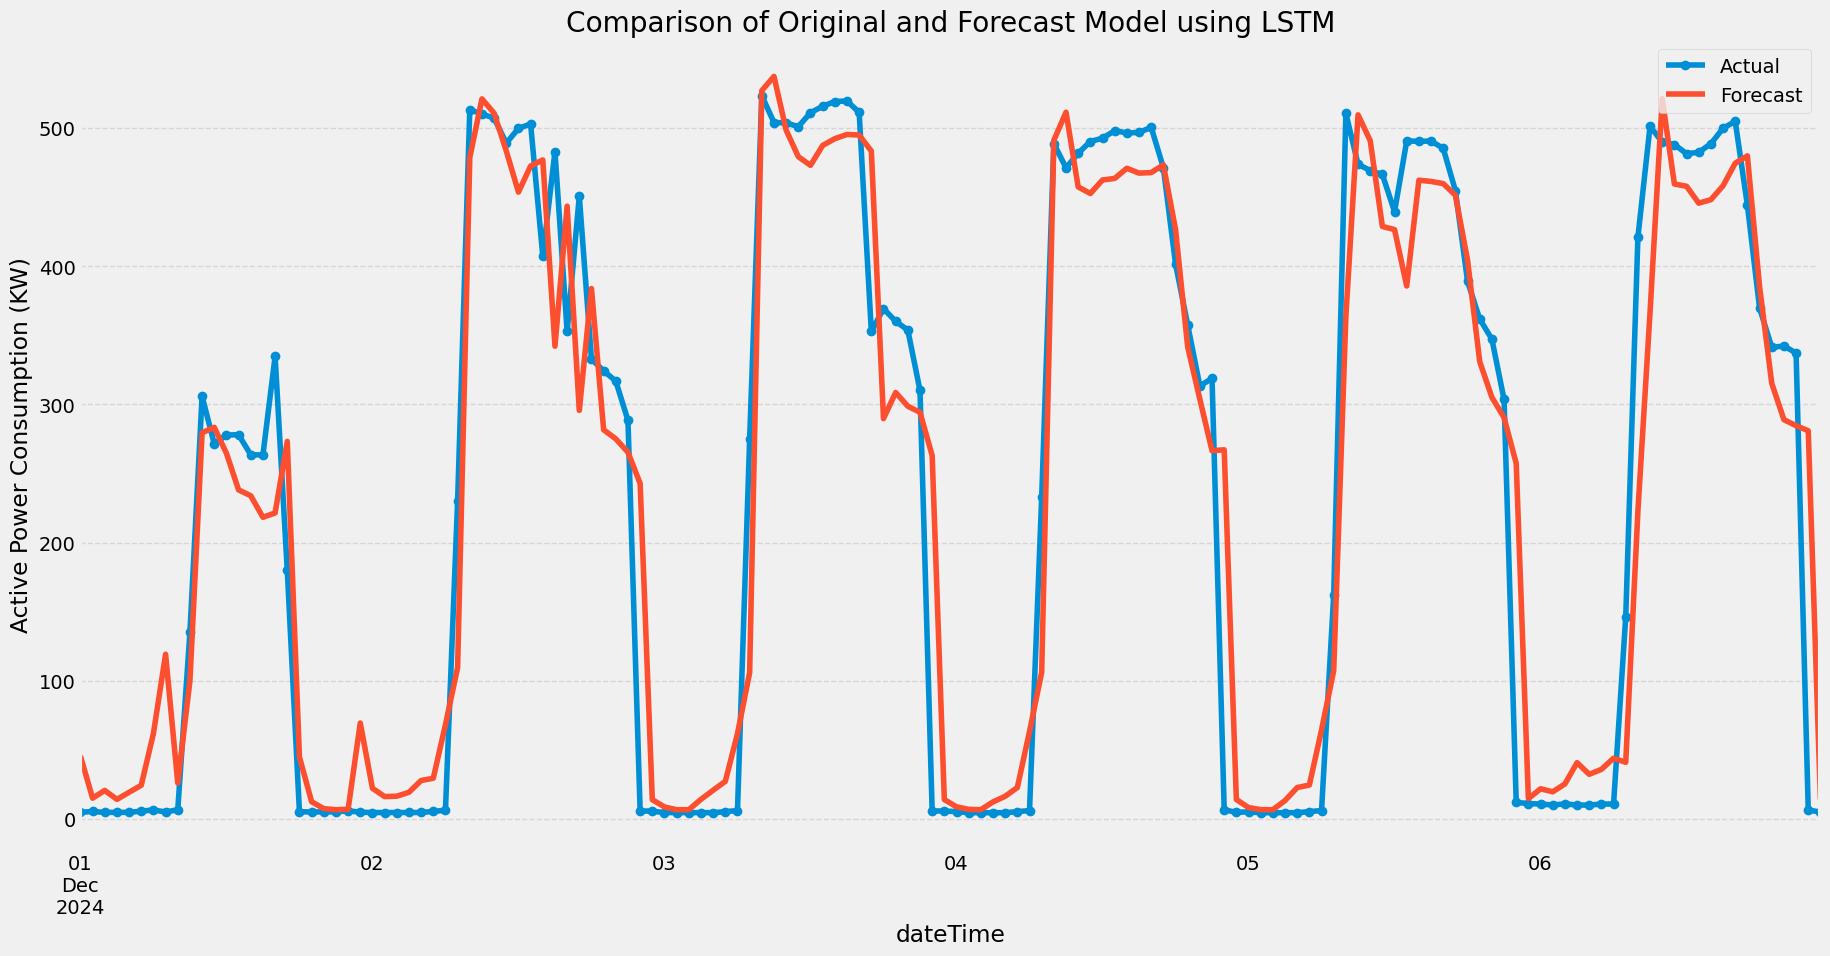

In [ ]:
predictions = model.predict(X_test).flatten()

df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df= df[['activePowerT']]
df = create_features(df)
df = df.reset_index()
dftest = df.iloc[min(val_idx+4):max(val_idx)]
dftest.set_index('dateTime', inplace=True)

df_lstm = pd.DataFrame(data={'Val Predictions': predictions, 'Actuals':y_test},index=dftest.index)



ax = df_lstm.loc[(df_lstm.index >= '2024-12-01') & (df_lstm.index < '2024-12-08')].plot(y=['Actuals'],title='Comparison of Original and Forecast Model using LSTM',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10),marker="o")
df_lstm.loc[(df_lstm.index >= '2024-12-01') & (df_lstm.index < '2024-12-08')].plot(y=['Val Predictions'],ax=ax)



ax.legend(['Actual','Forecast'],loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()

## SARIMA

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df['activePowerT'] = df['activePowerT'].astype(float)
fold = 0
sarima_score_mse = []
sarima_score_mae = []
sarima_score_r2 = []
preds = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    SARIMAX_model = SARIMAX(train['activePowerT'],order=(1,0,0),seasonal_order=(1,1,1,24))
    result = SARIMAX_model.fit()
    predictions = result.predict(start=train_idx.max()+1,end=val_idx.max())
    preds.append(predictions)
    sarima_score_mse.append(mean_squared_error(test['activePowerT'],predictions))
    sarima_score_mae.append(mean_absolute_error(test['activePowerT'],predictions))
    sarima_score_r2.append(r2_score(test['activePowerT'],predictions))

## SARIMA Forecasts

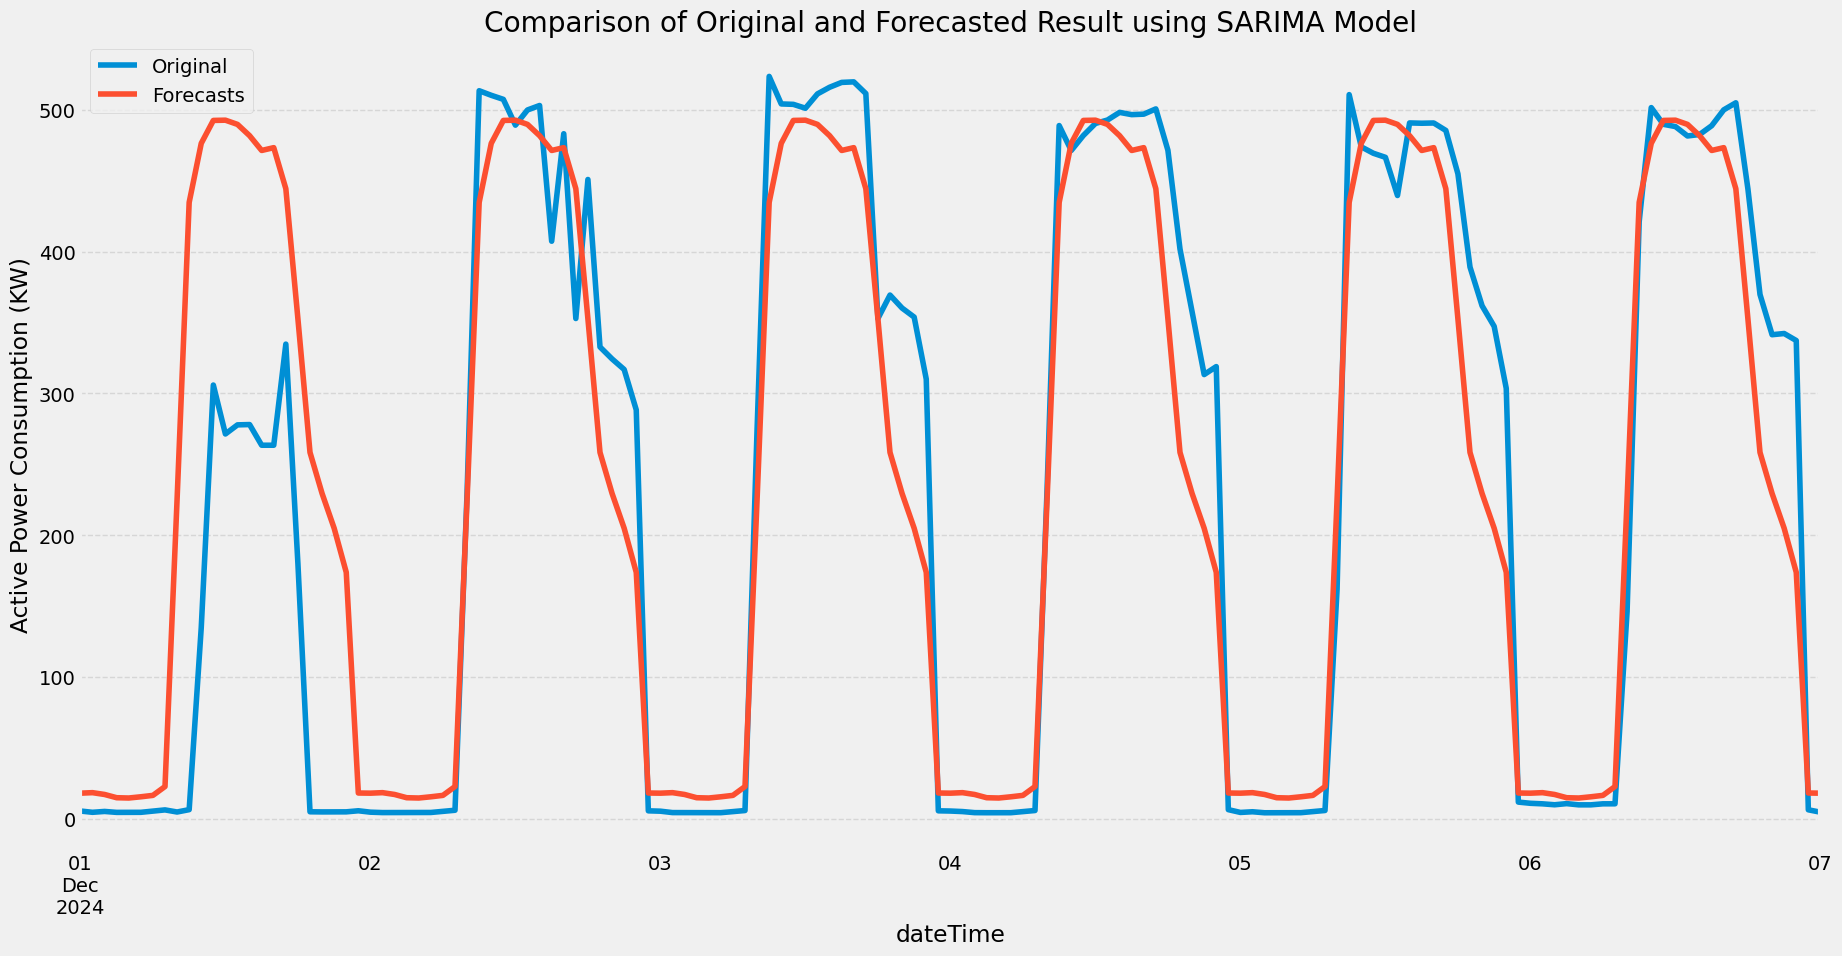

In [ ]:
predictions = result.predict(start=train_idx.max()+1,end=val_idx.max())
predictions.index = test['activePowerT'].index

ax = df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['activePowerT'],title='Comparison of Original and Forecasted Result using SARIMA Model',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(20,10))
predictions.loc[(predictions.index >= '2024-12-01') & (predictions.index < '2024-12-08')].plot(ax=ax,label="Forecasts")
ax.legend(['Original','Forecasts'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Seasonal Naive

In [ ]:
snaive_fc =[]
test= create_features(test)
for row_idx,row in test.iterrows():
    day = row['hour']
    forecast = test['activePowerT'].loc[test['hour']==day].iloc[-1]
    snaive_fc.append(forecast)
snaive_fc = pd.Series(snaive_fc,index=test.index)

## Seasonal Naive Forecast

In [ ]:
fold = 0
snaive_score_mse = []
snaive_score_mae = []
snaive_score_r2 = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    test= create_features(test)
    snaive_fc=[]
    for row_idx,row in test.iterrows():
        day = row['hour']
        forecast = test['activePowerT'].loc[test['hour']==day].iloc[-1]
        snaive_fc.append(forecast)
    snaive_fc = pd.Series(snaive_fc,index=test.index)

    snaive_score_mse.append(mean_squared_error(test['activePowerT'],snaive_fc))
    snaive_score_mae.append(mean_absolute_error(test['activePowerT'],snaive_fc))
    snaive_score_r2.append(r2_score(test['activePowerT'],snaive_fc))

## Overall Comparison

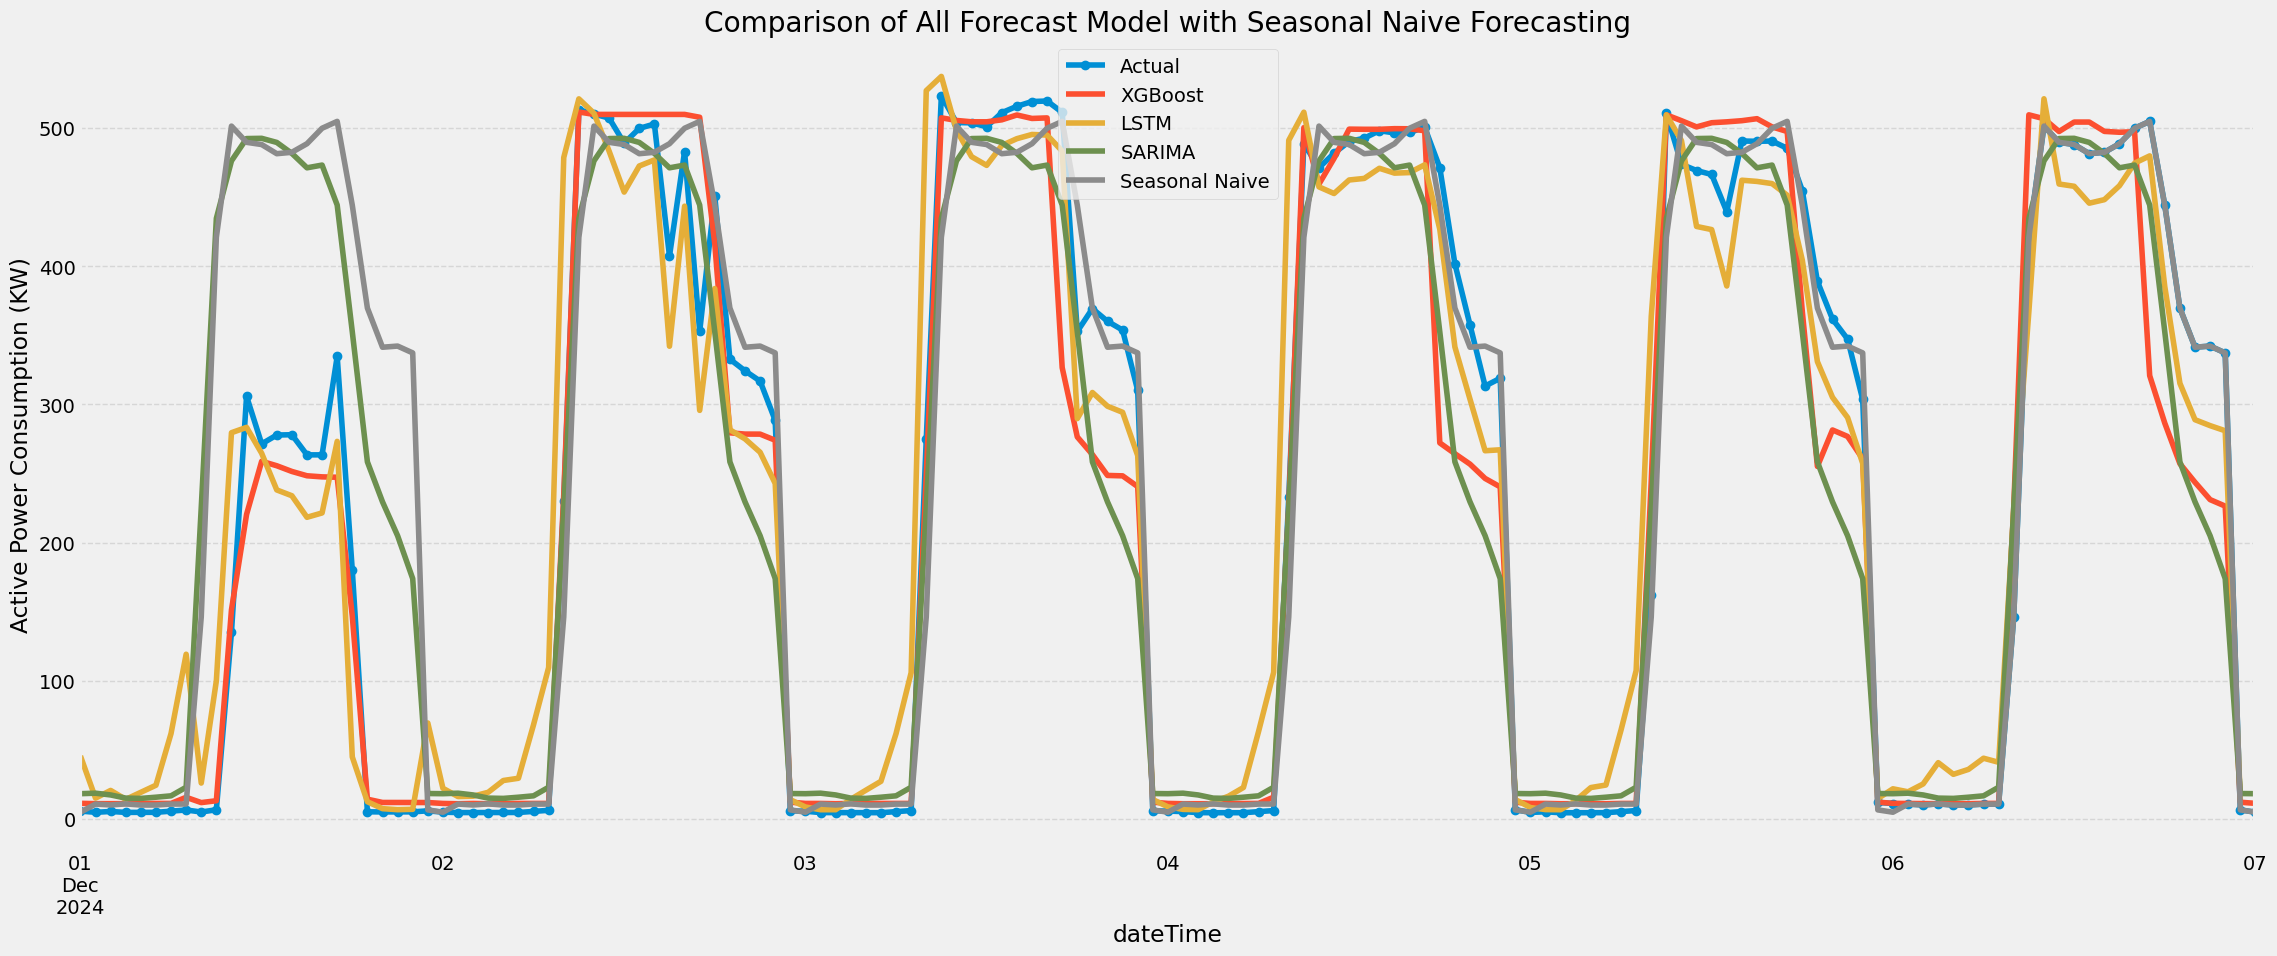

In [ ]:
ax = df_xgb.loc[(df_xgb.index >= '2024-12-01') & (df_xgb.index < '2024-12-08')].plot(y=['activePowerT'],title='Comparison of All Forecast Model with Seasonal Naive Forecasting',xlabel='Date',ylabel='Active Power Consumption (KW)',figsize=(25,10),marker="o")
df_xgb.loc[(df_xgb.index >= '2024-12-01') & (df_xgb.index < '2024-12-08')].plot(y=['pred'],ax=ax)
df_lstm.loc[(df_lstm.index >= '2024-12-01') & (df_lstm.index < '2024-12-08')].plot(y=['Val Predictions'],ax=ax)
predictions.loc[(predictions.index >= '2024-12-01') & (predictions.index < '2024-12-08')].plot(ax=ax,label="Forecasts")
snaive_fc.loc[(snaive_fc.index >= '2024-12-01') & (snaive_fc.index < '2024-12-08')].plot(ax=ax,label="Seasonal Naive")
ax.legend(['Actual','XGBoost','LSTM','SARIMA','Seasonal Naive'],loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Final/Results')

In [ ]:
print(f"MSE (Seasonal Naive):",np.mean(snaive_score_mse))
print(f"MAE (Seasonal Naive):",np.mean(snaive_score_mae))
print(f"R2 (Seasonal Naive):",np.mean(snaive_score_r2))
print(f"MSE (XGBoost):",np.mean(xgb_score_mse))
print(f"MAE (XGBoost):",np.mean(xgb_score_mae))
print(f"R2 (XGBoost):",np.mean(xgb_score_r2))
print(f"MSE (LSTM):",np.mean(lstm_score_mse))
print(f"MAE (LSTM):",np.mean(lstm_score_mae))
print(f"R2 (LSTM):",np.mean(lstm_score_r2))
print(f"MSE (SARIMA):",np.mean(sarima_score_mse))
print(f"MAE (SARIMA):",np.mean(sarima_score_mae))
print(f"R2 (SARIMA):",np.mean(sarima_score_r2))


MSE (Seasonal Naive): 16506.005612605008
MAE (Seasonal Naive): 66.33647609126983
R2 (Seasonal Naive): 0.6594340195242214
MSE (XGBoost): 8262.37392886928
MAE (XGBoost): 45.64984665157681
R2 (XGBoost): 0.8303608324587696
MSE (LSTM): 4649.304518939593
MAE (LSTM): 41.33726849264449
R2 (LSTM): 0.8922749097712563
MSE (SARIMA): 20838.396363570977
MAE (SARIMA): 91.81708188565237
R2 (SARIMA): 0.5718123108348176
